In [31]:
import os
import requests
import mne
import re
from tqdm import tqdm
import optuna
import zipfile
import numpy as np
import csv
import torch
import datetime
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch.optim.lr_scheduler import ExponentialLR
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scikeras.wrappers import KerasClassifier
from ray import tune, train
from ray.train import report
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler

import torchvision.transforms as transforms
from scipy.signal import welch, find_peaks
from scipy.linalg import hankel, eigh
from sklearn.decomposition import FastICA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
from PIL import Image
import matplotlib.pyplot as plt
from IPython import display as disp
from scipy.fftpack import fft, ifft  # Correct way
import warnings
from sklearn.cross_decomposition import CCA

from scipy.signal import butter, filtfilt
from scipy.signal import detrend
from collections import defaultdict, Counter

import shutil
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")
print('Imports complete.')
print(device)

Using device: cuda
Imports complete.
cuda


In [36]:
class EEGFeatureDataset(Dataset):
    def __init__(self, data_dir, num_features=4):
        """
        Args:
            data_dir (str): Path to the folder with extracted feature .npy files.
            num_features (int): Number of features per channel (default = 4).
        """
        self.data_dir = data_dir
        self.num_features = num_features

        # Match feature files
        pattern = re.compile(r"subject_\d+_video_\d+_segment_\d+_features\.npy")
        self.feature_files = sorted([f for f in os.listdir(data_dir) if pattern.match(f)])

        self.label_mapping = {
            'Happy': 0,
            'Surprise': 1,
            'Disgust': 2,
            'Fear': 3,
            'Anger': 4,
            'Sad': 5,
            'Neutral': 6
        }

    def __len__(self):
        return len(self.feature_files)

    def __getitem__(self, index):
        feature_file = self.feature_files[index]

        # Extract subject, video, segment from filename
        parts = feature_file.split("_")
        subject_id = parts[1]
        video_idx = parts[3]
        segment_idx = parts[5]
#         print(subject_id)

        # Load features (shape: [num_channels, num_features])
        feature_path = os.path.join(self.data_dir, feature_file)
        features = np.load(feature_path, allow_pickle=True)

        feature_vector = []
#         print(features)
#         print(f"Loaded features: {type(features)}, shape: {features.shape}")
        # Initialize a list to store the features for all channels
        feature_vector = []

        # Loop through each channel's features and extract the 4 features
        for channel_features in features:
            # Extract the 4 features per channel
            channel_data = [
                channel_features["SampleEntropy"],
                channel_features["TsallisEntropy"],
                channel_features["HiguchiFD"],
                channel_features["HurstExponent"]
            ]

            # Append to the feature vector
            feature_vector.append(channel_data)

        # Convert the feature vector into a numpy array (shape: [num_channels, num_features])
        feature_vector = np.array(feature_vector, dtype=np.float32)

        # Convert to a torch tensor
        X = torch.tensor(feature_vector, dtype=torch.float32)
#         print(X.shape)  # Should print: (num_channels, 4)

        
        # Convert to torch tensor
#         X = torch.tensor(features, dtype=torch.float32)  # Shape: (channels, features)
#         print(X)
        # Load label
        label_file = f"subject_{subject_id}_video_{video_idx}_segment_{segment_idx}_label.npy"
        label_path = os.path.join(self.data_dir, label_file)
        label_dict = np.load(label_path, allow_pickle=True).item()
        label = label_dict[int(segment_idx)]

        if isinstance(label, str):
            label = self.label_mapping.get(label, -1)

        return X, torch.tensor(label, dtype=torch.long)

# Example usage
dataset = EEGFeatureDataset(data_dir="CIF_MATRIX")
# Split dataset
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Check a batch from the train loader
for X, y in train_loader:
    print("Train Batch PCC shape:", X.shape)
    print("Train Batch Labels:", y) 
    break

for X, y in test_loader:
    print("Test Batch PCC shape:", X.shape)
    print("Test Batch Labels:", y) 
    break
    
print(f'Training size {train_size}')
print(len(train_loader))
print(f'Testing Size {test_size}')
print(len(test_loader))

Train Batch PCC shape: torch.Size([128, 11, 4])
Train Batch Labels: tensor([4, 3, 6, 2, 2, 6, 1, 5, 1, 4, 2, 3, 4, 6, 1, 4, 4, 4, 1, 4, 1, 5, 5, 2,
        1, 5, 2, 0, 2, 1, 5, 5, 2, 4, 1, 2, 3, 2, 3, 1, 4, 1, 6, 1, 4, 2, 2, 5,
        2, 0, 0, 4, 5, 4, 2, 3, 4, 3, 1, 5, 6, 0, 0, 4, 2, 0, 1, 0, 1, 0, 1, 4,
        6, 6, 0, 4, 1, 2, 4, 4, 1, 2, 1, 1, 3, 1, 0, 4, 4, 6, 4, 0, 2, 3, 2, 3,
        1, 4, 3, 0, 5, 1, 2, 1, 3, 4, 0, 1, 0, 5, 0, 0, 6, 6, 1, 0, 1, 0, 4, 5,
        3, 1, 4, 6, 0, 0, 2, 4])
Test Batch PCC shape: torch.Size([128, 11, 4])
Test Batch Labels: tensor([0, 1, 0, 3, 6, 4, 3, 4, 6, 0, 4, 4, 6, 1, 2, 3, 6, 5, 4, 0, 6, 0, 0, 1,
        6, 4, 5, 4, 0, 2, 0, 0, 2, 1, 5, 2, 1, 4, 4, 3, 0, 1, 3, 2, 2, 5, 1, 1,
        6, 2, 4, 4, 2, 4, 6, 3, 1, 5, 2, 0, 1, 3, 3, 2, 4, 4, 0, 1, 4, 0, 2, 4,
        6, 5, 3, 2, 5, 3, 0, 4, 2, 5, 3, 0, 4, 1, 4, 6, 6, 2, 5, 2, 1, 5, 6, 6,
        6, 0, 1, 5, 2, 5, 4, 0, 6, 1, 5, 5, 4, 4, 3, 4, 6, 2, 2, 3, 0, 2, 5, 5,
        1, 1, 0, 1, 2, 1, 5, 5])


In [29]:
all_labels = []

# Make sure your model/dataset is in evaluation mode
for inputs, labels in test_loader:
    all_labels.extend(labels.numpy())  # or labels.cpu().numpy() if using GPU

# Convert to NumPy array (optional)
all_labels = np.array(all_labels)


# Assuming all_labels is a NumPy array or a flat list of true labels
class_counts = Counter(all_labels)
classes = sorted(class_counts.keys())
counts = [class_counts[c] for c in classes]

# Optional: replace with actual emotion names
class_names = ['Happy', 'Sad', 'Angry', 'Surprised', 'Disgust', 'Fear', 'Neutral']

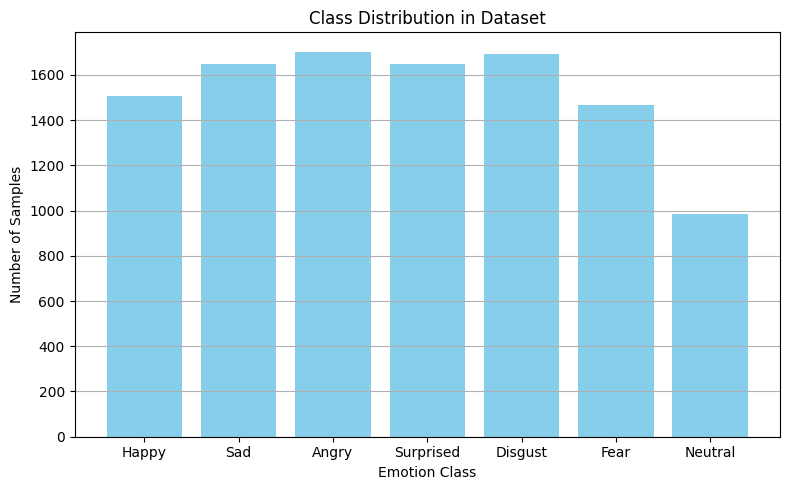

In [30]:
plt.figure(figsize=(8, 5))
plt.bar(class_names, counts, color='skyblue')
plt.title('Class Distribution in Dataset')
plt.xlabel('Emotion Class')
plt.ylabel('Number of Samples')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [20]:
class EEG_CNN(nn.Module):
    def __init__(self, num_classes=7, num_conv_layers=3, filters=16, fc_size=128, input_size=4, input_channels=11):
        super(EEG_CNN, self).__init__()
        original_filters= filters
        layers = []
        in_channels = 1  # Input channels for EEG PCC matrices
        current_size = input_size  # Track feature map size
        current_channels = input_channels
        for i in range(num_conv_layers):
            layers.append(nn.Conv2d(in_channels, filters, kernel_size=3, padding=1))
            layers.append(nn.BatchNorm2d(filters))
            layers.append(nn.LeakyReLU(0.1))
            layers.append(nn.MaxPool2d(kernel_size=2, stride=1))
            in_channels = filters  # Update for next layer
            
            if i == 2:
                layers.append(nn.Dropout(0.015))
            current_size = current_size - 1  # Each pooling reduces size by 1 (stride=1, kernel_size=2)
            current_channels = current_channels - 1
            filters = filters * 2
        
        self.conv_layers = nn.Sequential(*layers)
        # Compute dynamically the input size for fc1
        last_filters = original_filters * (2 ** (num_conv_layers - 1))
        
        # Compute correct input size for fc1 dynamically
        flattened_size = last_filters * current_size * current_channels
        self.fc1 = nn.Linear(flattened_size, fc_size)  # Adjust shape based on pooling
        self.fc2 = nn.Linear(fc_size, num_classes)
    
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv_layers(x)
#         x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
        x = self.fc2(x)
        return x

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = EEG_CNN(num_classes=7, num_conv_layers=7, filters=16, fc_size=256).to(device)
model = EEG_CNN(num_classes=7, num_conv_layers=3, filters=32, fc_size=128).to(device)

print(f'> Number of parameters {len(torch.nn.utils.parameters_to_vector(model.parameters()))}')
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0022525598641897388, weight_decay=0.00021556586541389503)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.01, patience=3)
final_test = 0

# Tracking variables
train_accuracies = []
test_accuracies = []
train_losses = []
val_losses = []

# Training loop
epochs = 30
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    test_acc_arr = np.zeros(0)
    train_acc_arr = np.zeros(0)
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        pred = outputs.argmax(dim=1, keepdim = True)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        train_acc_arr = np.append(train_acc_arr, pred.data.eq(labels.view_as(pred)).float().mean().item())
    
    avg_train_loss = running_loss / len(train_loader)
    avg_train_acc = train_acc_arr.mean()

    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")
    model.eval()
    val_loss = 0.0
    # iterate over the entire test dataset
    for x,t in test_loader:
        x,t = x.to(device), t.to(device)
        p = model(x)
        loss = torch.nn.functional.cross_entropy(p, t)
        pred = p.argmax(dim=1, keepdim=True)
        test_acc_arr = np.append(test_acc_arr, pred.data.eq(t.view_as(pred)).float().mean().item())
        val_loss += loss.item()
    
    avg_val_loss = val_loss / len(test_loader)
    avg_test_acc = test_acc_arr.mean()

    val_losses.append(avg_val_loss)
    test_accuracies.append(avg_test_acc)

    val_loss /= len(test_loader)
    final_test = test_acc_arr.mean()
    print(f'test acc: {test_acc_arr.mean()}, train acc:{train_acc_arr.mean()}')
    scheduler.step(val_loss)

torch.save(model.state_dict(), "eeg_model.pth")

print("Training complete!")

> Number of parameters 225223
Epoch [1/30], Loss: 1.9084
test acc: 0.20827132942421095, train acc:0.19456956958448565
Epoch [2/30], Loss: 1.8327
test acc: 0.26587301599127905, train acc:0.2458552302451463
Epoch [3/30], Loss: 1.7166
test acc: 0.3419828869047619, train acc:0.3143221346644668
Epoch [4/30], Loss: 1.5645
test acc: 0.40842013912541525, train acc:0.39039039039039036
Epoch [5/30], Loss: 1.3692
test acc: 0.44872271872702096, train acc:0.4817239114114114
Epoch [6/30], Loss: 1.1511
test acc: 0.537109375, train acc:0.5762872248440534
Epoch [7/30], Loss: 0.9695
test acc: 0.6344246034111295, train acc:0.6493602978574621
Epoch [8/30], Loss: 0.8025
test acc: 0.5543154761904762, train acc:0.7129160411007054
Epoch [9/30], Loss: 0.6712
test acc: 0.7417534724587486, train acc:0.7640374750346393
Epoch [10/30], Loss: 0.5869
test acc: 0.7395213296016058, train acc:0.7971330705705706
Epoch [11/30], Loss: 0.5321
test acc: 0.7654699903158915, train acc:0.8184903654250296
Epoch [12/30], Loss: 0.

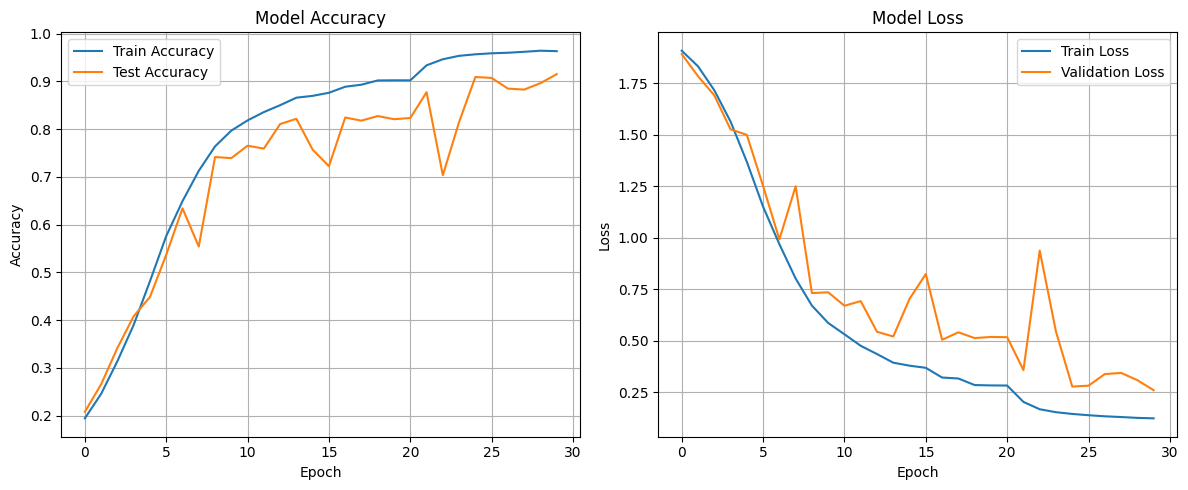

In [23]:
# Plot Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [24]:
def train_eeg_cnn(config):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dataset = EEGFeatureDataset(data_dir=config["data_path"])
    # Split dataset
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

    # Create DataLoaders
    trainloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    valloader = DataLoader(test_dataset, batch_size=32, shuffle=False)


    model = EEG_CNN(
        num_classes=7,
        num_conv_layers=3,
        filters=config["filters"],
        fc_size=config["fc_size"],
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.05, patience=3)


    for epoch in range(25):  # More if you like
        model.train()
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # Evaluate accuracy
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in valloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        acc = correct / total
        scheduler.step(acc)
    train.report({"accuracy": acc})

In [9]:
# Get absolute path and format it correctly for pyarrow
abs_path = os.path.abspath("ray_results")
storage_path = f"file://{abs_path}"


search_space = {
    "lr": tune.loguniform(3e-3, 1e-2),
    "filters": tune.choice([8, 16, 32]),
    "fc_size": tune.choice([64, 128, 256]),
    "weight_decay": tune.loguniform(1e-3,1e-2),
    "data_path": os.path.abspath("CIF_MATRIX"),
}

scheduler = ASHAScheduler(metric="accuracy", mode="max")
reporter = CLIReporter(metric_columns=["accuracy", "training_iteration"])

tune.run(
    train_eeg_cnn,
    resources_per_trial={"cpu": 2, "gpu": 1 if torch.cuda.is_available() else 0},
    config=search_space,
    num_samples=20,
    scheduler=scheduler,
    progress_reporter=reporter,
    storage_path=storage_path,
    name="tune_eeg_cnn"
)

2025-04-09 11:21:54,550	INFO worker.py:1852 -- Started a local Ray instance.
2025-04-09 11:22:05,847	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `tune.run(...)`.
2025-04-09 11:22:05,852	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


== Status ==
Current time: 2025-04-09 11:22:06 (running for 00:00:00.30)
Using AsyncHyperBand: num_stopped=0
Bracket: Iter 64.000: None | Iter 16.000: None | Iter 4.000: None | Iter 1.000: None
Logical resource usage: 0/64 CPUs, 0/1 GPUs (0.0/1.0 accelerator_type:A100)
Result logdir: /tmp/ray/session_2025-04-09_11-21-52_194839_1489401/artifacts/2025-04-09_11-22-05/tune_eeg_cnn/driver_artifacts
Number of trials: 20/20 (20 PENDING)
+---------------------------+----------+-------+-----------+-----------+------------+----------------+
| Trial name                | status   | loc   |   fc_size |   filters |         lr |   weight_decay |
|---------------------------+----------+-------+-----------+-----------+------------+----------------|
| train_eeg_cnn_7c6da_00000 | PENDING  |       |       128 |        32 | 0.00762549 |     0.00498937 |
| train_eeg_cnn_7c6da_00001 | PENDING  |       |       128 |        16 | 0.00315662 |     0.0011903  |
| train_eeg_cnn_7c6da_00002 | PENDING  |       |   

2025-04-09 11:23:05,477	WARNING tune.py:219 -- Stop signal received (e.g. via SIGINT/Ctrl+C), ending Ray Tune run. This will try to checkpoint the experiment state one last time. Press CTRL+C (or send SIGINT/SIGKILL/SIGTERM) to skip. 
2025-04-09 11:23:05,490	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home2/gmjv35/ray_results/tune_eeg_cnn' in 0.0111s.


== Status ==
Current time: 2025-04-09 11:23:05 (running for 00:00:59.57)
Using AsyncHyperBand: num_stopped=0
Bracket: Iter 64.000: None | Iter 16.000: None | Iter 4.000: None | Iter 1.000: None
Logical resource usage: 2.0/64 CPUs, 1.0/1 GPUs (0.0/1.0 accelerator_type:A100)
Result logdir: /tmp/ray/session_2025-04-09_11-21-52_194839_1489401/artifacts/2025-04-09_11-22-05/tune_eeg_cnn/driver_artifacts
Number of trials: 20/20 (19 PENDING, 1 RUNNING)
+---------------------------+----------+-----------------------+-----------+-----------+------------+----------------+
| Trial name                | status   | loc                   |   fc_size |   filters |         lr |   weight_decay |
|---------------------------+----------+-----------------------+-----------+-----------+------------+----------------|
| train_eeg_cnn_7c6da_00000 | RUNNING  | 10.234.204.81:1501992 |       128 |        32 | 0.00762549 |     0.00498937 |
| train_eeg_cnn_7c6da_00001 | PENDING  |                       |       128 

KeyboardInterrupt: 

(train_eeg_cnn pid=1501992) /home2/gmjv35/deeplearningenv/lib/python3.9/site-packages/ray/train/_internal/session.py:772: RayDeprecationWarning: `ray.train.report` should be switched to `ray.tune.report` when running in a function passed to Ray Tune. This will be an error in the future. See this issue for more context: https://github.com/ray-project/ray/issues/49454
(train_eeg_cnn pid=1501992)   _log_deprecation_warning(


In [26]:
# Reinitialize model architecture
loaded_model = EEG_CNN(num_classes=7, num_conv_layers=3, filters=32, fc_size=128).to(device)  # Make sure the architecture matches
loaded_model.load_state_dict(torch.load("eeg_model.pth"))
loaded_model.eval()  # Set to evaluation mode

# Move to the correct device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loaded_model.to(device)

/tmp/ipykernel_3015373/1571672833.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load("eeg_model.pth"))


EEG_CNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.1)
    (7): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.1)
    (11): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout(p=0.015, inplace=False)
  )
  (fc1): Linear(in_features=1024, out_features=128, 

In [36]:
subject_data = np.load("CIF_MATRIX/subject_1_video_3_segment_30_features.npy",allow_pickle=True)
label_mapping = {
            'Happy': 0,
            'Surprise': 1,
            'Disgust': 2,
            'Fear': 3,
            'Anger': 4,
            'Sad': 5,
            'Neutral': 6
        }

feature_vector = []

# Loop through each channel's features and extract the 4 features
for channel_features in subject_data:
    # Extract the 4 features per channel
    channel_data = [
        channel_features["SampleEntropy"],
        channel_features["TsallisEntropy"],
        channel_features["HiguchiFD"],
        channel_features["HurstExponent"]
    ]

    # Append to the feature vector
    feature_vector.append(channel_data)

# Convert the feature vector into a numpy array (shape: [num_channels, num_features])
feature_vector = np.array(feature_vector, dtype=np.float32)

# Convert to a torch tensor
X = torch.tensor(feature_vector, dtype=torch.float32)
# Reshape to [batch_size=1, num_channels=11, height=1, width=4]
X = X.unsqueeze(0)  # Add batch dimension (1, 11, 1, 4)
# Pass the EEG signals through the model to get predictions
# Move to the correct device (CPU or GPU)
X = X.to(device)

with torch.no_grad():  # Disable gradient calculation during inference
    output = loaded_model(X)  # Get model output
# If the output is logits, convert it to probabilities using softmax
probabilities = torch.softmax(output, dim=1)

# Get the predicted class (index with maximum probability)
predicted_class_idx = torch.argmax(probabilities, dim=1).item()  # Get the class index (scalar)

# Reverse the label mapping to get the emotion from the class index
reverse_label_mapping = {v: k for k, v in label_mapping.items()}
predicted_emotion = reverse_label_mapping.get(predicted_class_idx, "Unknown")

# Print the predicted emotion
print(f"Predicted emotion: {predicted_emotion}")

Predicted emotion: Disgust


In [27]:
# Put model in evaluation mode
loaded_model.eval()

# Store all predictions and true labels
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = loaded_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


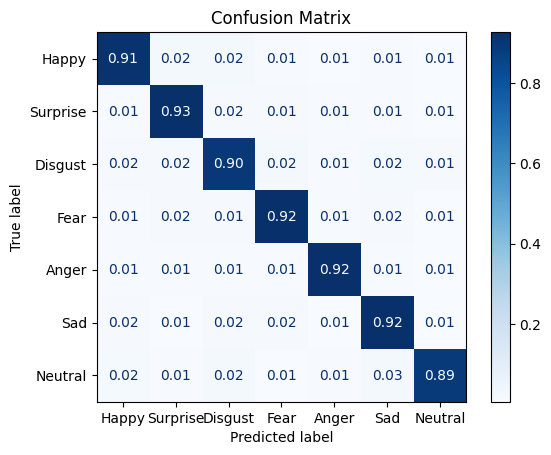

In [28]:
cm = confusion_matrix(all_labels, all_preds, normalize='true')

class_names = ['Happy', 'Surprise','Disgust','Fear','Anger','Sad','Neutral']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format=".2f")
plt.title("Confusion Matrix")
plt.show()


In [32]:
# Assuming all_preds and all_labels are now populated
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Precision: 0.9150
Recall:    0.9149
F1-score:  0.9149


In [11]:
print(final_test)

0.9391801075268817
